In [1]:
# ── 라이브러리 import (한 번만 실행; 이후 모든 셀이 이 이름을 그대로 사용) ──
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score, roc_curve

# ── 0. 환경 설정 ──────────────────────────────────────────────
# (1) 라이브러리 import — 이후 모든 셀이 여기서 불러온 이름을 그대로 사용

# 그래프 기본 스타일(선택)
sns.set_theme(style="whitegrid")

# (2) 시드 설정 — 본인 학번 뒷 4자리를 넣으세요 (예: 2026-12345 → 2345)
MY_SEED = 2041              # TODO: 학번 뒷 4자리
np.random.seed(2041)        # TODO: MY_SEED로 난수 생성기 고정

# (3) 데이터 로드 — 공개 URL 우선, 실패 시 업로드한 로컬 파일로 대체
# 데이터 로드: 공개 URL에서 바로 읽습니다(업로드 불필요). 실패 시 업로드한 로컬 파일 사용.
DATA_URL = "https://raw.githubusercontent.com/GauravPadawe/Framingham-Heart-Study/master/framingham.csv"
try:
    df = pd.read_csv(DATA_URL)
except Exception:
    df = pd.read_csv("framingham.csv")   # Colab: 좌측 파일 탭에 framingham.csv 업로드 후

# 이후 섹션 전체가 공유하는 수치형 열 목록
num_cols = ["age", "sysBP", "diaBP", "totChol", "BMI", "glucose", "heartRate"]

# 로드 확인
print("데이터 크기 (행, 열):", df.shape)          # 기대: (4240, 16)
print("MY_SEED =", MY_SEED)
print("\n[첫 3행]")
print(df.head(3))
print("\n[열별 결측치 개수 (0이 아닌 것만)]")
print(df.isna().sum()[df.isna().sum() > 0])       # TODO: 결측이 어느 열에 있는지 확인


데이터 크기 (행, 열): (4240, 16)
MY_SEED = 2041

[첫 3행]
   male  age  education  currentSmoker  cigsPerDay  BPMeds  prevalentStroke  \
0     1   39        4.0              0         0.0     0.0                0   
1     0   46        2.0              0         0.0     0.0                0   
2     1   48        1.0              1        20.0     0.0                0   

   prevalentHyp  diabetes  totChol  sysBP  diaBP    BMI  heartRate  glucose  \
0             0         0    195.0  106.0   70.0  26.97       80.0     77.0   
1             0         0    250.0  121.0   81.0  28.73       95.0     76.0   
2             0         0    245.0  127.5   80.0  25.34       75.0     70.0   

   TenYearCHD  
0           0  
1           0  
2           0  

[열별 결측치 개수 (0이 아닌 것만)]
education     105
cigsPerDay     29
BPMeds         53
totChol        50
BMI            19
heartRate       1
glucose       388
dtype: int64


Q0. 데이터를 제대로 불렀는지 확인해 봅시다.

1. df.shape는 무엇인가요? 행(참가자) 수와 열(변수) 수를 본인이 본 실제 숫자로 적으세요.
df.shape=(4240, 16). 행 4240명, 열 16
2. 결측이 가장 많은 열은 무엇이고 몇 개인가요? Framingham은 결측이 있어 뒤 섹션에서 dropna() 처리가 필요하니, 어떤 열이 문제일지 미리 봐 두세요.
결측이 가장 많은 열은 glucose(388개)이다.
3. MY_SEED를 다른 값으로 바꿔 이 셀을 다시 실행하면 df.shape가 달라질까요? 왜 그런지 한 줄로 설명하세요.
MY_SEED 바꿔도 df.shape는 바뀌지 않는다. 시드는 난수 생성기 출발점이기 때문에 표본추출과 시뮬레이션처럼 무작위에만 영향을 주고 파일에서 데이터 읽어오는 건 무작위 과정이 아니기 때문이다.

In [2]:
# 1) 데이터 크기: (행 개수, 열 개수)
print("shape (행, 열):", df.shape)        # TODO: df의 크기(행,열)를 출력

# 2) 앞부분 5행 미리보기 — 값이 어떻게 생겼는지 눈으로 확인
print("\n=== df.head() ===")
print(df.head)                            # TODO: 앞 5행 미리보기

# 3) 열별 자료형 + 비결측(non-null) 개수 한눈에 보기
print("\n=== df.info() ===")
df.info                                 # TODO: 열별 dtype/비결측 개수 요약

# 4) 열별 결측치 개수 (많은 순으로 정렬)
print("\n=== 결측치 개수 df.isna().sum() ===")
na_counts = df.isna().sum().sort_values(ascending=False)   # TODO: 열별 결측 개수 세기
print(na_counts)

# 5) 결측이 있는 열만 골라 개수 + 비율(%)로 정리
na_only = na_counts[na_counts > 0]
na_table = pd.DataFrame({
    "결측개수": na_only,
    "결측비율(%)": (na_only / len(df) * 100).round(2),
})
print("\n=== 결측이 있는 열 (개수 + 비율) ===")
print(na_table)

# 6) 반응변수 TenYearCHD(0/1) 분포 확인
print("\n=== 반응변수 TenYearCHD 분포 ===")
print(df["TenYearCHD"].value_counts())           # TODO: 0/1 각각 몇 개인지 세기
print("양성(CHD=1) 비율: {:.1%}".format(df["TenYearCHD"].mean()))

# 7) 주인공 연속변수 sysBP 요약 통계
print("\n=== 주인공 변수 sysBP 요약 ===")
print(df["sysBP"].describe())                # TODO: 평균/표준편차/사분위 요약


shape (행, 열): (4240, 16)

=== df.head() ===
<bound method NDFrame.head of       male  age  education  currentSmoker  cigsPerDay  BPMeds  \
0        1   39        4.0              0         0.0     0.0   
1        0   46        2.0              0         0.0     0.0   
2        1   48        1.0              1        20.0     0.0   
3        0   61        3.0              1        30.0     0.0   
4        0   46        3.0              1        23.0     0.0   
...    ...  ...        ...            ...         ...     ...   
4235     0   48        2.0              1        20.0     NaN   
4236     0   44        1.0              1        15.0     0.0   
4237     0   52        2.0              0         0.0     0.0   
4238     1   40        3.0              0         0.0     0.0   
4239     0   39        3.0              1        30.0     0.0   

      prevalentStroke  prevalentHyp  diabetes  totChol  sysBP  diaBP    BMI  \
0                   0             0         0    195.0  106.0   70

1. df.shape 결과, 이 데이터의 행(사람 수) 과 열(변수 수) 은 각각 몇 개인가요? 예측할 반응변수와 주인공 연속변수의 이름은 무엇인가요?
- 행 4240명, 열 16개. 반응변수: TenYearCHD, 주인공 연속변수: sysBP

2. df.isna().sum() 에서 결측이 가장 많은 열은 무엇이고 몇 개(몇 %)인가요? sysBP에는 결측이 몇 개인가요?
- 결측이 제일 많은 열은 glucose, 388개,  sysBP는 결측 0개

3. TenYearCHD.value_counts() 에서 발병(1)과 무발병(0)은 각각 몇 명이고, 양성 비율은 약 몇 %인가요? 두 집단이 불균형한데, "무조건 0으로 예측"하면 정확도가 몇 %쯤일지 한 줄로 생각해 보세요.
- 발병(1)=644명, 무발병(0)=3596명, 양성비율은 약 15.2%
무조건 0으로 예측하면 정확도가 84.8%지만 발병자를 맞히지 못하는 모델이 된다.

4. 결측이 하나라도 있는 행을 전부 삭제하면(dropna) 표본이 크게 줄 수 있습니다. "전체 dropna" 대신 필요한 열만 골라 dropna 하는 편이 왜 나은지, glucose의 결측 비율(약 9%)을 근거로 설명해 보세요.
- glucose 결측이 9.15%(388개)인데 전체 dropna() 하면 이 열 하나 때문에 388행이 불필요하게 제거된다. glucose가 필요 없는 분석에서는 이 행들을 살릴 수 있으므로, 분석에 쓰는 열에만 선택적으로 dropna하는 것이 표본 손실을 최소화한다.

상관행렬 (Pearson):
             age  sysBP  diaBP  totChol    BMI  glucose  heartRate
age        1.000  0.394  0.206    0.263  0.136    0.122     -0.013
sysBP      0.394  1.000  0.784    0.209  0.327    0.141      0.182
diaBP      0.206  0.784  1.000    0.165  0.377    0.061      0.181
totChol    0.263  0.209  0.165    1.000  0.116    0.047      0.091
BMI        0.136  0.327  0.377    0.116  1.000    0.087      0.067
glucose    0.122  0.141  0.061    0.047  0.087    1.000      0.095
heartRate -0.013  0.182  0.181    0.091  0.067    0.095      1.000


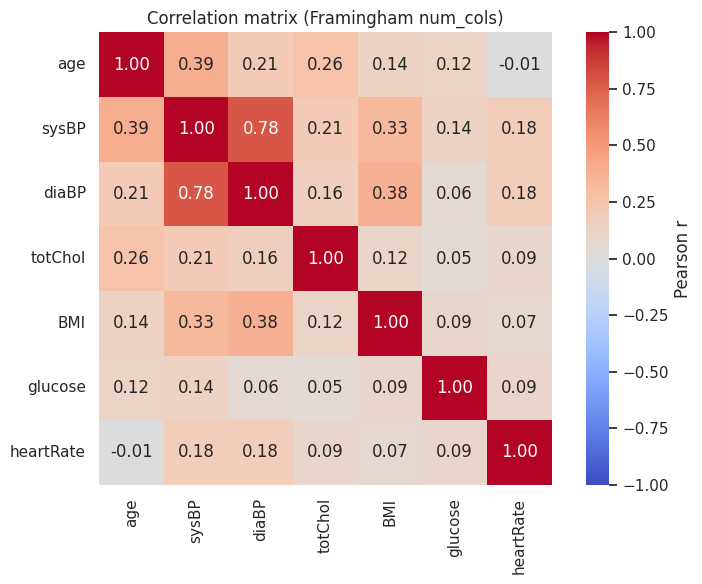


age - sysBP 상관계수 : 0.394
sysBP - diaBP 상관계수: 0.784


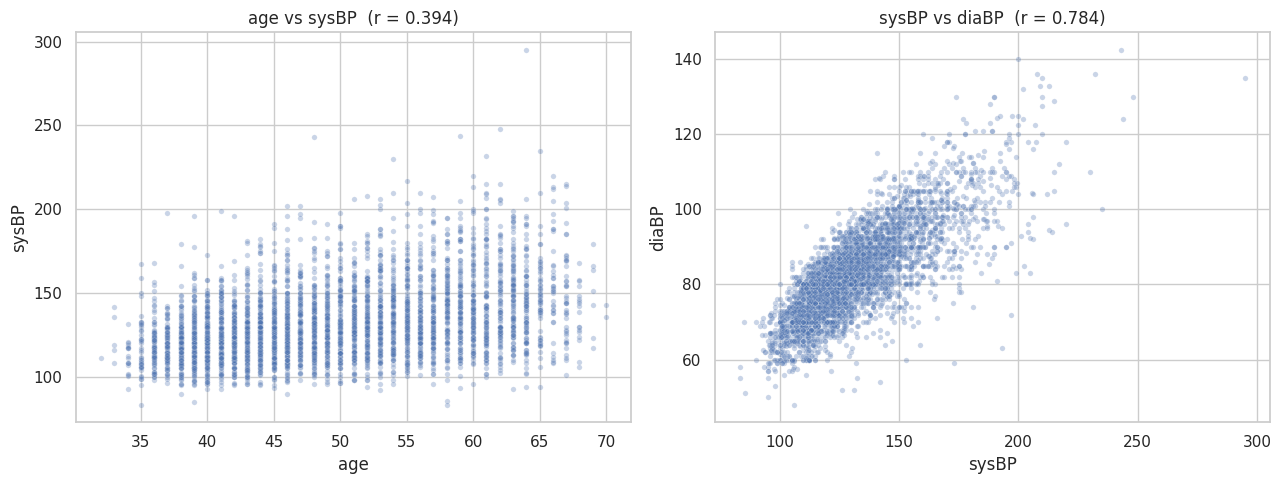

In [3]:
try:
    num_cols
except NameError:
    num_cols = ["age", "sysBP", "diaBP", "totChol", "BMI", "glucose", "heartRate"]

# 1) 상관행렬 계산 (연속형 변수만). Pearson 상관.
#    힌트: DataFrame에는 상관행렬을 바로 구하는 메서드가 있다.
corr = df[num_cols].corr()
print("상관행렬 (Pearson):")
print(corr.round(3))

# 2) 히트맵으로 시각화
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,                       # TODO: 무엇을 히트맵으로 그릴까?
    annot=True, fmt=".2f",
    cmap="coolwarm", center=0,
    vmin=-1, vmax=1, square=True,
    cbar_kws={"label": "Pearson r"},
)
plt.title("Correlation matrix (Framingham num_cols)")
plt.tight_layout()
plt.show()

# 3) 관심 상관 두 개를 명시적으로 추출 (해석 질문에서 인용할 값)
#    힌트: corr는 행/열이 변수명인 표 → .loc[행, 열] 로 특정 칸을 꺼낸다.
corr_age_sysBP = corr.loc["age", "sysBP"]
corr_sysBP_diaBP = corr.loc["sysBP", "diaBP"]
print(f"\nage - sysBP 상관계수 : {corr_age_sysBP:.3f}")
print(f"sysBP - diaBP 상관계수: {corr_sysBP_diaBP:.3f}")

# 4) 산점도 두 장: (a) age vs sysBP, (b) sysBP vs diaBP
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.scatterplot(data=df, x="age", y="sysBP", alpha=0.3, s=15, ax=axes[0])  # TODO: age vs sysBP
axes[0].set_title(f"age vs sysBP  (r = {corr_age_sysBP:.3f})")
axes[0].set_xlabel("age")
axes[0].set_ylabel("sysBP")

sns.scatterplot(data=df, x="sysBP", y="diaBP", alpha=0.3, s=15, ax=axes[1])  # TODO: sysBP vs diaBP
axes[1].set_title(f"sysBP vs diaBP  (r = {corr_sysBP_diaBP:.3f})")
axes[1].set_xlabel("sysBP")
axes[1].set_ylabel("diaBP")

plt.tight_layout()
plt.show()


1. age–sysBP 상관계수를 소수 셋째 자리까지 적으세요.
- age-sysBP 상관계수=0.394이고, 양수이므로 나이가 많을수록 수축기혈압이 높아지는 경향이 있다.

2. sysBP–diaBP 상관계수는 얼마였나요?
- sysBP-diaBP 상관계수=0.784이고, 수축기,이완기 혈압은 둘다 같은 심혈관 압력 메커니즘을 반영하시 때문에 높다. 히트맵에서 이 두 같이 0.78로 짙은 빨간색으로 표시되어 다중회귀에 함께 넣으면 계수 추정이 불안정해지는 공산성 문제가 생길 수 있다.

3. 두 변수의 상관이 0.02로 작게 나왔다면 "두 변수는 아무 관계가 없다"고 결론지어도 될까요? 산점도를 함께 봐야 하는 이유와 연결해 답하세요.
- 상관이 0이 나왔다고 해서 관계가 없음을 의미하지 않는다. 피어슨 상관은 직선의 관계만 잡기 때문에 비선형 강한 관계도 0이 나올 수 있따. 따라서 산점도를 함께 봐야 실제 관계를 파악할 수 있다.

In [5]:
!apt-get install -y fonts-nanum

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

fm.fontManager.__init__()

# 나눔고딕 경로 직접 지정
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 3 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 1s (11.2 MB/s)
Selecting previously unselected package fonts-nanum.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


모집단 크기 = 4240,  모집단 평균 = 132.35,  모집단 표준편차(sigma) = 22.03


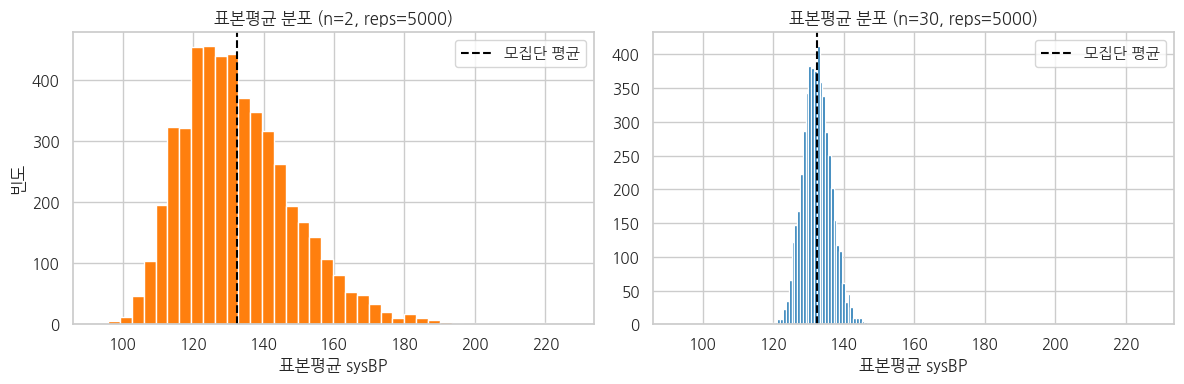

n= 2 | 경험 표준편차 = 15.828 | 이론값 sigma/sqrt(n) = 15.578
n=30 | 경험 표준편차 = 4.026 | 이론값 sigma/sqrt(n) = 4.022


In [6]:
# --- 0) 재현성: 시드 고정 ---
np.random.seed(MY_SEED)

# --- 1) sysBP 전체 값을 '모집단'으로 사용 (결측 제거) ---
pop = df["sysBP"].dropna().values          # TODO: 결측 제거 메서드
sigma = pop.std(ddof=0)                 # 모집단 표준편차 ~ 22
print(f"모집단 크기 = {len(pop)},  모집단 평균 = {pop.mean():.2f},  모집단 표준편차(sigma) = {sigma:.2f}")

# --- 2) 표본평균을 모으는 헬퍼: 직접 for 루프로 구현 (라이브러리에 통째로 맡기지 말 것!) ---
def sample_means(data, n, reps):
    means = []
    for _ in range(reps):
        sample = np.random.choice(data,size=n,replace=True)                   # TODO: data에서 크기 n 표본을 복원추출 (np.random.choice, replace=True)
        means.append(sample.mean())              # TODO: 그 표본의 평균을 기록
    return np.array(means)

# --- 3) n=2 vs n=30 으로 표본분포 만들기 ---
reps = 5000
means_n2  = sample_means(pop, n=2,  reps=reps)
means_n30 = sample_means(pop, n=30, reps=reps)

# --- 4) 두 히스토그램 나란히 비교 ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

axes[0].hist(means_n2, bins=40, color="tab:orange", edgecolor="white")
axes[0].axvline(pop.mean(), color="black", linestyle="--", label="모집단 평균")
axes[0].set_title(f"표본평균 분포 (n=2, reps={reps})")
axes[0].set_xlabel("표본평균 sysBP"); axes[0].set_ylabel("빈도"); axes[0].legend()

axes[1].hist(means_n30, bins=40, color="tab:blue", edgecolor="white")
axes[1].axvline(pop.mean(), color="black", linestyle="--", label="모집단 평균")
axes[1].set_title(f"표본평균 분포 (n=30, reps={reps})")
axes[1].set_xlabel("표본평균 sysBP"); axes[1].legend()

plt.tight_layout()
plt.show()

# --- 5) 경험 표준편차(표준오차) vs 이론값 sigma/sqrt(n) 비교 ---
for n, means in [(2, means_n2), (30, means_n30)]:
    emp = means.std(ddof=0)             # 시뮬레이션으로 얻은 표본평균들의 표준편차
    theo = sigma/np.sqrt(n)                         # TODO: CLT 이론값 = sigma / sqrt(n)
    print(f"n={n:>2} | 경험 표준편차 = {emp:.3f} | 이론값 sigma/sqrt(n) = {theo:.3f}")


1. n=2와 n=30의 히스토그램을 비교하세요. 어느 쪽이 더 좁고 종 모양에 가까웠나요? 두 분포의 중심은 모집단 평균(약 132)과 견주어 어디쯤이었나요?
- n=30이 더 좁고 종 모양에 가깝다. n=2는 넓고 불규칙하다. 두 분포의 중심은 각각 132.66(n=2), 132.27(n=30)으로 모집단 평균인 132.35에 가깝다.

2. 5번 셀의 경험 표준편차 두 값을 적고, 각각을 이론값  σ/n−−√ ( σ≈22 이므로  22/2–√≈15.6 ,  22/30−−√≈4.0 )과 비교하세요. n이 2에서 30으로 커질 때 표본평균의 흔들림(표준오차)은 어떻게 변했나요?
- n=2일때 경험 표준편차는 15.828, n=30일 때 경험 표준편차는 4.026이다. 이론값은 n=2일 때 15.578, n=30일 때 4.022이다. n이 2에서 30으로 커지면 표본평균의 표준오차가 약 1/4 수준으로 줄어든다.

3. 위 결과를 중심극한정리(CLT) 한 문장으로 요약하세요. (힌트: "표본크기 n이 커지면 표본평균의 분포는 ___에 가까워지고, 그 표준편차는 ___으로 줄어든다.")
- 표본크기 n이 커지면 표본평균의 분포는 정규분포에 가까워지고, 그 표준편차는 $\sigma/\sqrt{n}$으로 줄어든다.

관측된 sysBP 평균 (점추정): 132.35
부트스트랩 95% 신뢰구간: [131.70, 133.04]


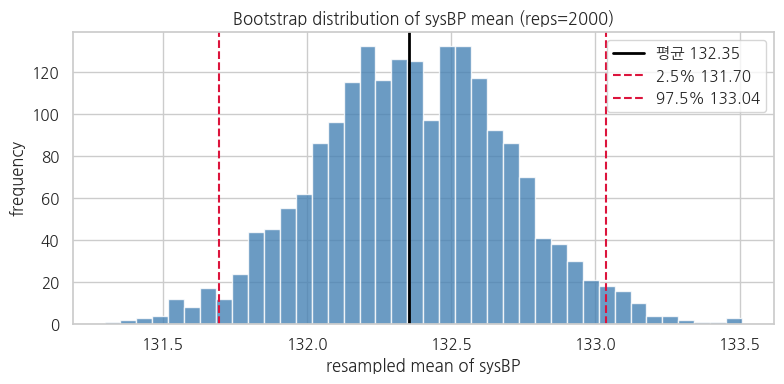

In [7]:
# === 1.4 신뢰구간: sysBP 평균의 95% CI를 부트스트랩으로 직접 구현 ===
# pop 은 1.3에서 만든 전체 sysBP 값 배열입니다. (없다면 아래 한 줄로 복구)
pop = df["sysBP"].dropna().values

n = len(pop)          # 표본 크기 (매 재표집도 이 크기로 뽑는다)
reps = 2000           # 재표집 반복 횟수
rng = np.random.default_rng(MY_SEED)   # 재현 가능한 난수 생성기

# 부트스트랩 평균들을 담을 그릇
boot_means = np.empty(reps)

for i in range(reps):
    # TODO: pop 에서 복원추출(중복 허용)로 n개 인덱스를 뽑아라 (힌트: rng.integers)
    idx = rng.integers(0,n,size=n)
    resample = pop[idx]
    # TODO: 그 표본의 평균을 boot_means[i] 에 기록하라
    boot_means[i] = resample.mean()

# TODO: boot_means 에서 2.5 / 97.5 백분위를 잘라 ci_low, ci_high 로 받아라
ci_low, ci_high = np.percentile(boot_means,[2.5,97.5])

print(f"관측된 sysBP 평균 (점추정): {pop.mean():.2f}")
print(f"부트스트랩 95% 신뢰구간: [{ci_low:.2f}, {ci_high:.2f}]")

# 부트스트랩 평균들의 분포 + CI 시각화 (보일러플레이트 — 그대로 두세요)
plt.figure(figsize=(8, 4))
plt.hist(boot_means, bins=40, color="steelblue", edgecolor="white", alpha=0.8)
plt.axvline(pop.mean(), color="black", linestyle="-", linewidth=2, label=f"평균 {pop.mean():.2f}")
plt.axvline(ci_low,  color="crimson", linestyle="--", linewidth=1.5, label=f"2.5% {ci_low:.2f}")
plt.axvline(ci_high, color="crimson", linestyle="--", linewidth=1.5, label=f"97.5% {ci_high:.2f}")
plt.title("Bootstrap distribution of sysBP mean (reps=2000)")
plt.xlabel("resampled mean of sysBP")
plt.ylabel("frequency")
plt.legend()
plt.tight_layout()
plt.show()


1. 방금 얻은 신뢰구간 [ci_low, ci_high]의 실제 값을 적으세요. 강의에서 예고한 대략 [131.7, 133.0]과 비슷한가요? (MY_SEED·reps에 따라 소수점은 달라집니다.)
- [131.70,133.04] 강의 예고와 거의 동일하게 나왔다.

2. 빈도주의 해석을 정확히 쓰세요. 다음 두 문장 중 옳은 것은 무엇이고, 왜 나머지는 틀렸는지 본인 CI 값을 넣어 설명하세요.
(A) "CI를 만드는 절차를 무한히 반복하면, 그 구간들 중 약 95%가 진짜 모평균을 포함한다."
(B) "진짜 sysBP 모평균이 내 구간 안에 있을 확률이 95%다."
→ 정답은 (A). 빈도주의에서 모평균은 고정값이고 무작위로 흔들리는 것은 구간 쪽이라, 확률 95%는 "이 특정 구간"이 아니라 "구간을 만드는 절차 전체"에 붙습니다. 이미 계산된 내 구간 하나는 참값을 포함했거나 안 했거나 둘 중 하나이므로, 여기에 95% 확률을 매기는 (B)는 베이지안식 표현이라 부정확합니다. (정답 노출?)
- A가 정답이다. 빈도주의에 sysBP 모평균은 하나로 고정된 값이다. 무작위로 흔들리는 것은 표본 뽑을 때마다 달라지는 구간이다. B가 틀린 이유는 [131.70,133.04]가 고정된 값이다. 진짜 모평균이 이 범위 안에 있거나 없거나 둘 중 하나이므로, 이 구간 하나에 95% 확률을 붙이는 것은 의미가 없다. B는 모평균 자체가 불확실하다가 보는 베이지안식 표현이다.


3. reps를 200으로 줄이면 CI 폭과 히스토그램 모양이 어떻게 달라질지 예상하고, 실제로 바꿔 실행해 확인하세요. (재표집 횟수는 CI의 '안정성'에 영향을 줄 뿐, 데이터 자체의 불확실성을 줄이지는 않습니다.)
- 아래 셀에서 실행해보면 reps=200으로 했을 때 [131.65, 132.99]로 나왔다. reps를 줄이면 부트스트랩 평균이 적게 쌓이기 때문에 히스토그램이 덜 부드러워진다. CI 폭 자체는 n이 결정하기 때문에 달라지지 않는다. reps=2000일때도 폭이 1.34이고 reps=200일 때도 폭이 1.34이다. 이를 통해 reps를 줄여도 CI 폭은 바뀌지 않고 히스토그램만 거칠어진다는 점, 즉 CI의 불확실성을 결정하는 것은 반복 횟수가 아니라 데이터크기 n임을 알수 있다.

관측된 sysBP 평균 (점추정): 132.35
부트스트랩 95% 신뢰구간: [131.65, 132.99]


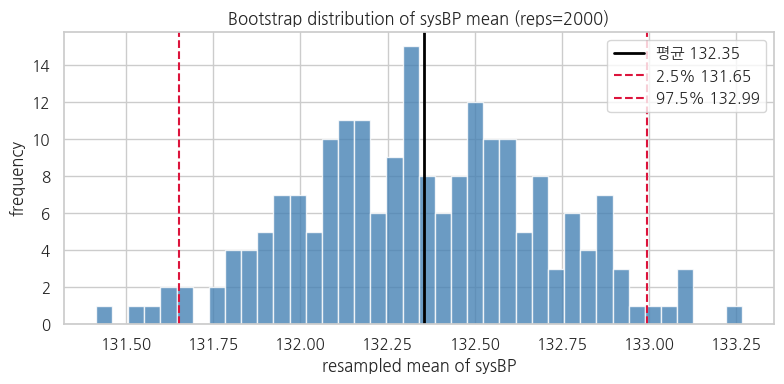

In [8]:
# === 1.4 신뢰구간: sysBP 평균의 95% CI를 부트스트랩으로 직접 구현 ===
# pop 은 1.3에서 만든 전체 sysBP 값 배열입니다. (없다면 아래 한 줄로 복구)
pop = df["sysBP"].dropna().values

n = len(pop)          # 표본 크기 (매 재표집도 이 크기로 뽑는다)
reps = 200          # 재표집 반복 횟수
rng = np.random.default_rng(MY_SEED)   # 재현 가능한 난수 생성기

# 부트스트랩 평균들을 담을 그릇
boot_means = np.empty(reps)

for i in range(reps):
    # TODO: pop 에서 복원추출(중복 허용)로 n개 인덱스를 뽑아라 (힌트: rng.integers)
    idx = rng.integers(0,n,size=n)
    resample = pop[idx]
    # TODO: 그 표본의 평균을 boot_means[i] 에 기록하라
    boot_means[i] = resample.mean()

# TODO: boot_means 에서 2.5 / 97.5 백분위를 잘라 ci_low, ci_high 로 받아라
ci_low, ci_high = np.percentile(boot_means,[2.5,97.5])

print(f"관측된 sysBP 평균 (점추정): {pop.mean():.2f}")
print(f"부트스트랩 95% 신뢰구간: [{ci_low:.2f}, {ci_high:.2f}]")

# 부트스트랩 평균들의 분포 + CI 시각화 (보일러플레이트 — 그대로 두세요)
plt.figure(figsize=(8, 4))
plt.hist(boot_means, bins=40, color="steelblue", edgecolor="white", alpha=0.8)
plt.axvline(pop.mean(), color="black", linestyle="-", linewidth=2, label=f"평균 {pop.mean():.2f}")
plt.axvline(ci_low,  color="crimson", linestyle="--", linewidth=1.5, label=f"2.5% {ci_low:.2f}")
plt.axvline(ci_high, color="crimson", linestyle="--", linewidth=1.5, label=f"97.5% {ci_high:.2f}")
plt.title("Bootstrap distribution of sysBP mean (reps=2000)")
plt.xlabel("resampled mean of sysBP")
plt.ylabel("frequency")
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
# 1.5 두 집단 평균차 t검정 (Welch) ----------------------------------
# TenYearCHD == 1 (10년 내 CHD 발생) vs == 0 각각의 sysBP (결측 제거)
g1 = df.loc[df["TenYearCHD"] == 1, "sysBP"].dropna().values   # CHD 발생군
g0 = df.loc[df["TenYearCHD"] == 0, "sysBP"].dropna().values                    # TODO: 비발생군 조건

print(f"CHD군    (n={len(g1)}): 평균 {g1.mean():.1f}, 표준편차 {g1.std(ddof=1):.1f}")
print(f"비CHD군  (n={len(g0)}): 평균 {g0.mean():.1f}, 표준편차 {g0.std(ddof=1):.1f}")

# 두 군의 분산이 다르므로(26.7 vs 20.5) Welch t검정
# TODO: stats.ttest_ind 로 Welch t검정 (분산 다름 옵션을 꼭 넣을 것)
t_stat, p_val = stats.ttest_ind(g1, g0, equal_var=False)

mean_diff = g1.mean() - g0.mean()   # 효과크기: 평균차
print(f"\n평균차(효과크기) = {mean_diff:.1f} mmHg")
print(f"Welch t = {t_stat:.2f},  p = {p_val:.2e}")

if p_val < 0.05:
    print("=> p < 0.05: 귀무가설(두 군 평균 같다) 기각")
else:
    print("=> p >= 0.05: 귀무가설 기각 실패")


CHD군    (n=644): 평균 143.6, 표준편차 26.7
비CHD군  (n=3596): 평균 130.3, 표준편차 20.5

평균차(효과크기) = 13.3 mmHg
Welch t = 12.01,  p = 1.25e-30
=> p < 0.05: 귀무가설(두 군 평균 같다) 기각


1. t_stat과 p_val은 각각 얼마인가요? 이 p값으로 "두 군의 sysBP 평균은 같다"는 귀무가설을 기각하나요, 기각에 실패하나요? 한 문장으로 판정하세요.
- t_stat=12.01, p_val=$1.25*10^{(-30)}$
p<0.05이므로 "두 군의 sysBP 평균은 같다"는 귀무가설을 기각한다.


2. p값을 "두 군의 sysBP가 우연히 이만큼 차이 날 확률"이라 하면 왜 부정확한가요? p값의 정의(귀무가설이 참이라 가정했을 때 이만큼 극단적인 결과가 나올 확률)를 살려 고쳐 쓰세요.
귀무가설이 참이라고 가정했을 때, 지금 관측된 것만큼 또는 더 극단적인 차이가 우연히 나올 확률이 약 $1.25*10^{(-30)}$이다. p값은 귀무가설이 참일 확률이나 관측된 차이가 실재로 존재할 확률이 아니다.

3. p값이 작다는 것만으로 "혈압 차이가 임상적으로 크다"고 결론 낼 수 있나요? 출력한 평균차( ≈13.3  mmHg) 를 인용해, p값(유의성)과 효과크기를 왜 둘 다 봐야 하는지 설명하세요. (n이 크면 작은 평균차도 p가 극단적으로 작아짐)
- p값만으로는 임상적으로 크다고 결론 낼 수 없다. p값은 차이가 0이 아니다만 말할 수 있을 뿐이지 크기를 말하지 않는다. 이 데이터에서 평균차=13.3mmHg 임상적으로 의미있지만 p값이 아니라 효과크기에서 읽어야한다. n이 커지면 실제 차이가 1mmHg이라해도 p값이 극단적으로 작을 수 있으므로 p값과 효과크기를 반드시 함께 봐야한다.

4. equal_var=False(Welch)를 쓴 이유를 두 군의 표준편차( ≈26.7  vs  ≈20.5 ) 를 인용해 한 문장으로 답하고, equal_var=True로 바꾸면 무엇이 달라질지 예상하세요.
- CHD군 표준편차는 약 26.7, 비CHD군은 약 20.5로 두 군의 분산이 다르기 때문에, 등분산을 가정하는 Student t 대신 자유도를 보정하는 equal_var=False(Welch)를 사용했다. 아래 셀처럼 equal_var=True로 바꾸면 두 군의 분산이 같다고 잘못 가정하게 되어 자유도 계산이 달라지고 t값이 약간 변한다. 다만 이 데이터처럼 n이 크면 결론(기각)은 동일하게 나온다.

In [10]:
# 1.5 두 집단 평균차 t검정 (Welch) ----------------------------------
# TenYearCHD == 1 (10년 내 CHD 발생) vs == 0 각각의 sysBP (결측 제거)
g1 = df.loc[df["TenYearCHD"] == 1, "sysBP"].dropna().values   # CHD 발생군
g0 = df.loc[df["TenYearCHD"] == 0, "sysBP"].dropna().values                    # TODO: 비발생군 조건

print(f"CHD군    (n={len(g1)}): 평균 {g1.mean():.1f}, 표준편차 {g1.std(ddof=1):.1f}")
print(f"비CHD군  (n={len(g0)}): 평균 {g0.mean():.1f}, 표준편차 {g0.std(ddof=1):.1f}")

# 두 군의 분산이 다르므로(26.7 vs 20.5) Welch t검정
# TODO: stats.ttest_ind 로 Welch t검정 (분산 다름 옵션을 꼭 넣을 것)
t_stat, p_val = stats.ttest_ind(g1, g0, equal_var=True)

mean_diff = g1.mean() - g0.mean()   # 효과크기: 평균차
print(f"\n평균차(효과크기) = {mean_diff:.1f} mmHg")
print(f"Welch t = {t_stat:.2f},  p = {p_val:.2e}")

if p_val < 0.05:
    print("=> p < 0.05: 귀무가설(두 군 평균 같다) 기각")
else:
    print("=> p >= 0.05: 귀무가설 기각 실패")


CHD군    (n=644): 평균 143.6, 표준편차 26.7
비CHD군  (n=3596): 평균 130.3, 표준편차 20.5

평균차(효과크기) = 13.3 mmHg
Welch t = 14.43,  p = 4.22e-46
=> p < 0.05: 귀무가설(두 군 평균 같다) 기각


                            OLS Regression Results                            
Dep. Variable:                  sysBP   R-squared:                       0.155
Model:                            OLS   Adj. R-squared:                  0.155
Method:                 Least Squares   F-statistic:                     779.0
Date:                Thu, 30 Jul 2026   Prob (F-statistic):          1.58e-157
Time:                        03:40:26   Log-Likelihood:                -18770.
No. Observations:                4240   AIC:                         3.754e+04
Df Residuals:                    4238   BIC:                         3.756e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     82.1420      1.826     44.992      0.0

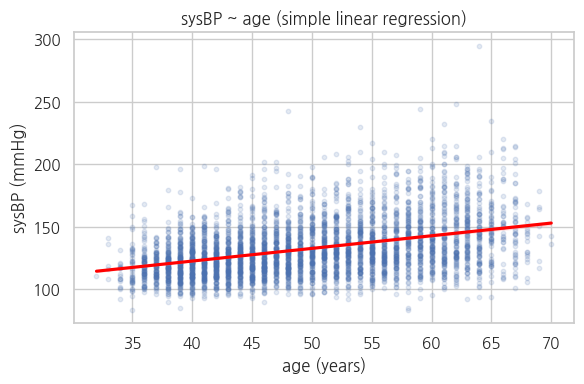

In [14]:
# age(설명변수) 하나로 sysBP(반응변수)를 예측하는 단순선형회귀
# TODO: "반응변수 ~ 설명변수" 공식으로 OLS 모형을 적합하세요 (.fit()까지)
model_simple = smf.ols("sysBP~age", data=df).fit()

# 회귀 결과 전체 요약표: 계수, 표준오차, t, p값, 95% CI, R^2 등
print(model_simple.summary())

# 핵심 값만 뽑아 보기
beta_age = model_simple.params["age"]          # age 기울기 계수
p_age    = model_simple.pvalues["age"]         # age 계수의 p값
ci_age   = model_simple.conf_int().loc["age"]  # age 계수의 95% 신뢰구간 [하한, 상한]
# TODO: 모형의 결정계수(R^2)를 꺼내세요 (model_simple 의 속성)
r2       = model_simple.rsquared

print(f"\nage 계수(기울기)  = {beta_age:.4f} mmHg / 1살")
print(f"age 계수 p값       = {p_age:.3e}")
print(f"age 계수 95% CI    = [{ci_age[0]:.4f}, {ci_age[1]:.4f}]")
print(f"R^2               = {r2:.4f}")

# 단순회귀에서 R^2 = (상관계수)^2 임을 직접 확인
r = df["age"].corr(df["sysBP"])
print(f"\ncorr(age, sysBP)  = {r:.4f},  r^2 = {r**2:.4f}  (== R^2)")

# 산점도 + 회귀직선으로 관계 시각화
plt.figure(figsize=(6, 4))
sns.regplot(x="age", y="sysBP", data=df,
            scatter_kws={"alpha": 0.15, "s": 10}, line_kws={"color": "red"})
plt.title("sysBP ~ age (simple linear regression)")
plt.xlabel("age (years)")
plt.ylabel("sysBP (mmHg)")
plt.tight_layout()
plt.show()


1. 본인이 얻은 age 계수는 얼마입니까? 문장으로 옮겨 보세요: "나이가 1살 많아질수록 수축기혈압(sysBP)은 평균 약 1.0128 mmHg 높아진다."

2. age 계수의 p값과 95% 신뢰구간을 인용하세요. 이 CI가 0을 포함하는지 확인하고, 그것이 "나이와 혈압 사이에 관계가 있다"는 주장과 어떻게 연결되는지 한 문장으로 설명하세요.
- p값은 $1.580 × 10^{(-157)}$, 95% CI = [0.9416, 1.0839].
CI가 0을 포함하지 않는다. 기울기가 0이라는 귀무가설(나이와 혈압 사이에 관계 없음)을 95% 신뢰수준에서 기각할 수 있으므로, 나이와 수축기혈압 사이에 통계적으로 유의한 양의 관계가 있다고 판단할 수 있다.

3. 본인의  R2 는 얼마입니까? corr(age, sysBP)의 제곱과 같은 값이 나왔나요? " R2  = ____ 이므로, 나이만으로 sysBP 변동의 약 ____%를 설명한다"를 채워 쓰세요.
- $R^2$=0.15553, corr(age,sysBP)=0.3941, $r^2=0.3941^2=0.1553$ 따라서 동일하게 나왔다. $R^2$ = 0.1553이므로, 나이만으로 sysBP 변동의 약 15.5%를 설명한다.

나머지 84.5%는 BMI, 흡연, 콜레스테롤 등 나이 이외의 요인으로 설명된다. $R^2$이 낮아도 p값=$10^{(-157)}$이므로 관계가 없는 게 아니라, 나이 하나만으로는 설명력이 부족하다는 의미다.

In [15]:
# 1.7 다중회귀 (범주형 포함)
# 연속형(age, BMI, totChol, glucose) + 범주형은 C(...)로 감싸 더미 처리
# statsmodels가 NaN 행을 자동 제외 → 실제 n이 줄어드는 점에 주의

# TODO: sysBP를 age, BMI, totChol, glucose(연속형) + male, currentSmoker, diabetes(범주형)로 설명하는 OLS
#       범주형 세 변수는 반드시 C(...)로 감쌀 것
model_multi = smf.ols(
    "sysBP ~ age + BMI + totChol + glucose + C(male) + C(currentSmoker) + C(diabetes)",
    data=df
).fit()

print(model_multi.summary())

# 결측 자동 제거로 실제 사용된 표본 크기 확인
print(f"\n전체 행수: {len(df)}")
print(f"다중회귀에 실제 사용된 n(nobs): {int(model_multi.nobs)}")   # TODO: model_multi에서 nobs 속성 사용
print(f"→ 결측으로 {len(df) - int(model_multi.nobs)}개 행 제외됨")

# 단순회귀(1.6) 대비 R² 상승 확인
print(f"\n단순회귀(age만) R²   = {model_simple.rsquared:.3f}")
print(f"다중회귀 R²          = {model_multi.rsquared:.3f}")   # TODO: model_multi의 R²
print(f"다중회귀 Adjusted R² = {model_multi.rsquared_adj:.3f}")


                            OLS Regression Results                            
Dep. Variable:                  sysBP   R-squared:                       0.245
Model:                            OLS   Adj. R-squared:                  0.244
Method:                 Least Squares   F-statistic:                     177.5
Date:                Thu, 30 Jul 2026   Prob (F-statistic):          3.63e-228
Time:                        03:55:32   Log-Likelihood:                -16739.
No. Observations:                3828   AIC:                         3.349e+04
Df Residuals:                    3820   BIC:                         3.354e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                39.04

1. model_multi.nobs는 전체 4,240에서 얼마로 줄었나요? 본인 값을 적고, 왜 줄었는지 한 줄로 설명하세요.
- model_multi.nobs=3828. 전체 4240에서 412개 행이 줄었다. glucose(388개), totChol(50개),BMI(19개) 중 하나라도 NaN인 행이 제외됐기 때문이다.

2. age 계수가 단순회귀(1.6)와 다중회귀에서 달라졌나요? 어느 쪽이 더 크고 왜 그럴 수 있을까요? (다른 변수를 '통제'한다는 것과 연결해 설명하세요.)
- 단순회귀 age 계수: 1.0128 mmHg/살. 다중회귀 age 계수: 0.8183 mmHg/살. 단순회귀에서 더 크다. 단순회귀에서는 나이와 함께 BMI랑 성별 등의 효과가 age 계수에 섞여 들어간다. 다중회귀에서 이 변수들을 함께 넣어 통제하면 나이의 순효과만 남아 계수가 줄어든다. 즉, 단순회귀의 age 계수 일부는 나이 많은 사람이 BMI도 높고 남성 비율도 다르다는 혼입 효과를 포함하고 있었다고 추론할 수 있다.

In [17]:
# === 1.8 해석 vs 예측: train/test 분할로 예측 성능 재기 ===
# 관점 전환: 1.6~statsmodels R²(in-sample, 해석) → 여기선 sklearn으로
# "처음 보는 test 데이터"에서의 예측 오차(RMSE·MAE)를 잰다.

# --- (1) 설계행렬 만들기 ---
target = "sysBP"
# TODO: 누수 방지 — sysBP(target)만 빼고 나머지를 설명변수 후보로. ____
feature_cols = [c for c in df.columns if c!=target]

# 결측이 있으면 학습이 안 된다 → 설명변수+목표를 함께 놓고 결측 '행' 제거.
# TODO: 아래에서 결측 행을 통째로 제거하는 메서드를 채워라. ____
design = df[feature_cols + [target]].dropna()

# education만 원핫 인코딩(one-hot), 나머지는 숫자 그대로.
# TODO: education을 원핫하도록 인자를 채워라. ____
X = pd.get_dummies(design[feature_cols], columns=["education"], drop_first=True)
y = design[target]

print("사용한 행 수:", len(design), "/ 설명변수 개수:", X.shape[1])

# --- (2) train/test 분할 (재현 위해 random_state=MY_SEED) ---
# TODO: test 비율 0.2, random_state=MY_SEED 로 분할. ____
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=MY_SEED
)
print("train:", X_train.shape[0], " test:", X_test.shape[0])

# --- (3) 학습은 train에서만 ---
# TODO: train 데이터로만 적합. ____
lin = LinearRegression().fit(X_train, y_train)

# --- (4) 평가는 test에서만 ---
y_pred = lin.predict(X_test)
# TODO: RMSE = sqrt(MSE), MAE 를 test에서 계산. ____
rmse = np.sqrt(metrics.mean_squared_error(y_test, y_pred))
mae  = metrics.mean_absolute_error(y_test, y_pred)

print(f"[예측 관점] test RMSE = {rmse:.3f} mmHg")
print(f"[예측 관점] test MAE  = {mae:.3f} mmHg")
print(f"RMSE - MAE 간격 = {rmse - mae:.3f}")

# --- (5) 해석 지표(in-sample R²)와 나란히 비교 ---
X_sm = sm.add_constant(X.astype(float))
ols_all = sm.OLS(y, X_sm).fit()
print(f"[해석 관점] in-sample R^2 = {ols_all.rsquared:.3f}")


사용한 행 수: 3658 / 설명변수 개수: 17
train: 2926  test: 732
[예측 관점] test RMSE = 11.397 mmHg
[예측 관점] test MAE  = 8.481 mmHg
RMSE - MAE 간격 = 2.915
[해석 관점] in-sample R^2 = 0.736


1. test RMSE = 11.397 mmHg 와 MAE = 8.481 mmHg 를 적으세요. test RMSE가 더 크다. RMSE가 항상 MAE보다 큰 이유는 RMSE가 오차를 제곱한 뒤 평균을 내기 때문에, 크게 빗나간 예측에 더 큰 벌점이 붙어 값이 올라간다. RMSE − MAE = 2.916으로, 간격이 클수록 극단적으로 빗나간 예측이 일부 존재한다는 신호다.

2. RMSE는 "예측이 평균 약 몇 mmHg 빗나간다"로 읽습니다. 본인 RMSE를 sysBP의 표준편차( ≈22  mmHg)와 비교하면 어느 정도인가요? 이 모델은 전체 평균으로 찍는 것보다 나은가요?
- sysBP 표준편차는 22mmHg, test RMSE=11.97mmHg로 절반 정도이다. 전체 평균으로만 찍는 모델의 RMSE는 표준편차와 같으므로 그것보다는 약 2배 정도 정확하다. 그러나 개인 혈압 예측 오차가 평균 약 11mmHg이기 떄문에 임상도구로 쓰기엔 여전히 크다.

3. R2 (in-sample) 와 test RMSE 가 각각 답하는 질문을 한 문장씩 쓰세요. ( R2  → "데이터를 얼마나 잘 설명하나?", RMSE → "새 환자를 얼마나 잘 맞히나?") 이 구분이 리뷰 논문 Shmueli, "To Explain or to Predict?" 의 핵심입니다.
- $R^2$ (in-sample) → 이 학습 데이터의 sysBP 변동을 모델이 얼마나 잘 설명하는가?
test RMSE → 처음 보는 새 환자의 sysBP를 이 모델이 얼마나 정확히 맞히는가?

4. " R2 이 높으면 예측도 잘한다"가 항상 맞나요?  R2 을 학습에 쓴 데이터에서 재면 왜 예측 성능의 증거가 되기 어려운지, train/test 분할이 왜 필요했는지 본인 말로 설명하세요.
- $R^2$ 이 높으면 예측도 잘한다는 항상 맞지 않는다. in-sample $R^2$ = 0.736으로 매우 높지만 test RMSE = 11.397 mmHg로 여전히 크다. $R^2$ 을 학습 데이터에서 계산하면 모델이 그 데이터의 패턴을 외울수록 높아지는데, 이것이 새 데이터에서도 잘 맞힌다는 것을 보장하지는 않는다. train/test 분할은 모델이 한 번도 보지 못한 데이터로 성능을 재어, 이 외우기 효과를 배제하고 진짜 예측 성능을 공정하게 평가하기 위해 필요하다.

In [18]:
# 2-A. 진짜 관심사 TenYearCHD(0/1)를 '그냥' 선형회귀로 예측해 본다.
# (formula 방식은 결측이 있는 행을 자동으로 제외하고 적합한다.)
m_lpm = smf.ols("TenYearCHD ~ age + sysBP + BMI", data=df).fit()
pred = m_lpm.fittedvalues   # 각 사람에 대한 선형회귀 예측값

# TODO: 예측값의 최솟값과 최댓값을 출력하라.
print("예측값 min :", pred.min())
print("예측값 max :", pred.max())

# TODO: 예측값이 0보다 작은 사람 수, 1보다 큰 사람 수를 세어 출력하라.
n_below0 = int((pred<0).sum())
n_above1 = int((pred>1).sum())
print("0보다 작은 예측값을 받은 사람 수 :", n_below0)
print("1보다 큰 예측값을 받은 사람 수 :", n_above1)
print("적합에 실제로 쓰인 관측치 수 :", int(m_lpm.nobs))


예측값 min : -0.07071488414938026
예측값 max : 0.6461474980212303
0보다 작은 예측값을 받은 사람 수 : 89
1보다 큰 예측값을 받은 사람 수 : 0
적합에 실제로 쓰인 관측치 수 : 4221


(1) 선형회귀는 출력값 범위에 제한이 없으므로, 변수 조합에 따라 0~1을 벗어나는 예측값이 생길 것이다.

(2) 예측값 min = −0.0707, max = 0.6461
0보다 작은 예측값을 받은 사람 수 = 89명
1보다 큰 예측값을 받은 사람 수 = 0명

(3) 예측값 min = −0.0707로 0 미만인 사람이 89명 나왔다. 확률은 0~1 사이여야 하는데 음수 예측값이 나왔으므로 확률로 여길 수 없다.

1 초과인 사람은 0명이었지만 이것이 안전하다고 보장해주는 것은 아니다. 선형회귀는 구조적으로 출력 범위를 제한하지 않기 때문에, age, sysBP, BMI가 더 극단적인 새 환자가 들어오면 예측값이 1을 넘을 수 있다. 이번 데이터 범위 안에서 우연히 1 초과가 없었을 뿐, 항상 0~1에 있다는 보장은 없다.

(4) TenYearCHD(0/1)처럼 이진 결과를 예측할 때 선형회귀를 쓰면 예측값이 확률의 수학적 요건(0 이상 1 이하)을 만족하지 못한다. 위 셀에서도 89명이 음수 예측값을 받았다. 로지스틱 회귀는 이 문제를 시그모이드 함수로 해결한다. 선형 결합값 z가 아무리 크거나 작아도 시그모이드를 적용하면 출력이 항상 (0, 1) 사이로 압축된다. 따라서 어떤 극단적인 환자 값이 입력돼도 예측값이 확률 요건을 만족하기 때문에 이진 반응 예측에 로지스틱 회귀가 필요하다.

In [20]:
# 2-B. 로지스틱 회귀 = Framingham Risk Score 엔진.  진짜 표적 TenYearCHD(0/1) 예측.
feat_log = ['age', 'male', 'sysBP', 'totChol', 'currentSmoker', 'glucose', 'BMI']
d_log = df[feat_log + ['TenYearCHD']].dropna()          # TODO: 결측 제거(dropna)
print("사용 표본 수:", len(d_log), "/ 전체:", len(df))

logit_model = smf.logit(
    "TenYearCHD ~ age + male + sysBP + totChol + currentSmoker + glucose + BMI",
    data=d_log).fit(disp=0)

# TODO: 계수에 np.exp() 를 취해 오즈비(odds_ratio) 열을 만들라.
or_table = pd.DataFrame({
    'coef': logit_model.params,
    'odds_ratio': np.exp(logit_model.params),                               # TODO: np.exp(logit_model.params)
    'p_value': logit_model.pvalues,
})
print(or_table.round(4).to_string())

# 각 사람의 10년 발병 '확률' 예측 (2-A의 선형회귀와 달리 항상 0~1 안에 있는지 확인)
p_hat = logit_model.predict(d_log)
print("\n예측 확률 min / max :", round(float(p_hat.min()), 4), "/", round(float(p_hat.max()), 4))

# TODO: roc_auc_score(정답 라벨, 예측 확률) 로 ROC-AUC 를 구하라.
auc_log = roc_auc_score(d_log['TenYearCHD'], p_hat)    # TODO: p_hat
print("ROC-AUC :", round(auc_log, 4))

사용 표본 수: 3828 / 전체: 4240
                 coef  odds_ratio  p_value
Intercept     -9.4547      0.0001   0.0000
age            0.0645      1.0666   0.0000
male           0.6402      1.8969   0.0000
sysBP          0.0169      1.0171   0.0000
totChol        0.0027      1.0027   0.0125
currentSmoker  0.3943      1.4834   0.0001
glucose        0.0074      1.0074   0.0000
BMI            0.0126      1.0127   0.2937

예측 확률 min / max : 0.0131 / 0.9382
ROC-AUC : 0.7366


(1) 오즈비 읽기. odds_ratio에서 1보다 큰 변수 2개와 1에 가깝거나 p값이 유의하지 않은 변수 1개를 값과 함께 적고, 각각 "한 단위 증가가 10년 발병 오즈를 몇 배로 바꾸는가"를 한 문장으로 해석하세요.
- male(OR=1.897) 다른 조건이 같을 때 남성은 여성 대비 10년 CHD 발병 오즈가 약 1.90배 높다.
- currentSmoker(OR=1.483) 현재 흡연하는 사람은 비흡연자 대비 발병 오즈가 약 1.48배 높다.
- 1에 가깝고 p값이 유의하지 않은 변수는 BMI(OR=1.013, p=0.294) 다른 변수 통제하면 BMI 1단위 커졌을 때 10년 발병 오즈를 약 1.01배 바꾸고, 통계적으로 유의하지 않다.

(2) 범위 문제 해결 확인. 로지스틱 예측 확률의 min/max는 얼마였나요(본인 값)? 2-A의 선형회귀 예측값(0~1 이탈)과 나란히 놓고, 로지스틱이 "확률" 요구를 어떻게 만족시키는지 본인 숫자로 설명하세요.
- 선형회귀(2-A): min = −0.0707, max = 0.6461 이므로 음수 예측값 89명 발생
로지스틱: min = 0.0131, max = 0.9382 이므로 전원 0~1 안에 있음

로지스틱은 시그모이드 함수로 출력을 구조적으로 (0, 1) 범위로 압축하기 때문에, 어떤 입력이 들어와도 확률 요건을 항상 만족한다.

(3) 성능은 하나로 판단하지 않기. 본인 ROC-AUC는 얼마이며 무작위(0.5)보다 나은가요? 이 값 하나로 "좋은 모델"이라 단정할 수 있는지, 없다면 무엇을 더 봐야 하는지(예: 양성 비율 불균형, 확률 캘리브레이션) 하나 이상 적으세요.
- ROC-AUC = 0.7366으로 무작위(0.5)보다 유의미하게 높지만 이 값 하나로 좋다고 판단할 수는 없다. 이 데이터는 양성(CHD=1) 비율이 15.2%로 불균형하기 때문에, AUC가 높아도 실제 발병자를 얼마나 잡아내는지는 별도로 확인해야 한다. 또한 예측 확률 0.3이 실제 발병률 30%에 해당하는지 등 캘리브레이션도 점검해야 임상 도구로 신뢰할 수 있다.

(4) 큰 그림 완성. 지금 만든 로지스틱이 왜 "Framingham Risk Score의 엔진"인지, 이 과제가 강의(연속형 sysBP에서 멈춤)를 어떻게 이어서 완성하는지, 절차①(검정)→절차②(회귀)→표적 예측 흐름으로 2~3문장 정리하세요.
- 절차①(t검정)으로 CHD군과 비CHD군에서 sysBP·나이 등이 유의하게 다름을 확인하고, 절차②(회귀)로 각 위험인자의 순효과 크기(오즈비)를 추정했다. 이 계수들을 결합해 개인별 10년 발병 확률을 계산하는 것이 로지스틱 모델이고 Framingham Risk Score의 통계적 엔진이다. 강의가 연속형 sysBP의 선형회귀에서 멈춘 것을 과제를 통해 이진 표적 TenYearCHD의 로지스틱 예측까지 이어 완성했다.

In [21]:
# --- 판단에 쓸 두 숫자 다시 확인 (근거로 인용할 값) ---
# 1) 설명 관점: 다중회귀 R^2
_predictors = ["age", "BMI", "totChol", "glucose", "heartRate", "cigsPerDay"]
_d = df[["sysBP"] + _predictors].dropna()
_mult = smf.ols("sysBP ~ " + " + ".join(_predictors), data=_d).fit()
print(f"[설명] 다중회귀 R^2 = {_mult.rsquared:.3f}   (n = {_d.shape[0]})")

# 2) 예측 관점: test RMSE 를 출력하라 (앞 셀에서 만든 rmse 변수 사용)
# TODO: print(...)
print(f"[예측] test RMSE = {rmse:.3f} mmHg")

# 이 두 숫자를 아래 서술형 답의 근거로 인용할 것.

[설명] 다중회귀 R^2 = 0.266   (n = 3802)
[예측] test RMSE = 11.397 mmHg


(1) 혈압계 측정 오차가 임상적으로 ±5 mmHg 이내면 신뢰할 수 있다는 기준을 적용하면, test RMSE = 11.397 mmHg는 이 기준의 두 배 이상이다. 기준을 통과하지 못한다.

(2) A: $R^2$ = 0.266. 어떤 요인이 혈압과 연관되는지 말하는 근거로 쓸 수 있다.
써도 되는 이유: age, BMI, glucose 등의 계수가 통계적으로 유의하며, 각 변수가 다른 변수를 통제했을 때 sysBP와 얼마나 연관되는지 방향과 크기를 보여준다.
조심할 이유: $R^2$ = 0.266은 이 변수들이 sysBP 변동의 26.6%만 설명한다는 뜻이다. 나머지 73.4%는 모델에 없는 요인에서 영향을 받는다. 관측 데이터의 연관이지 인과가 아니므로 이런 요인을 관리하면 혈압이 내려간다고 단정할 수는 없다.
B: test RMSE = 11.397 mmHg. 기준(±5 mmHg)을 초과하므로 새 환자 혈압을 맞힌다고 내놓기 어렵다. 평균 찍는 것(22 mmHg)보다는 두 배 정도 정확하지만, 개인 수준에서 약 11 mmHg의 오차는 경계를 넘나들 수 있어 임상 판단이 정확하지는 않다.

(3) Shmueli의 논지를 이 데이터가 뒷받침한다고 생각한다.

$R^2$ = 0.266으로 age나 BMI 등 여러 변수가 sysBP와 유의미하게 연관됨을 설명하지만, test RMSE = 11.397 mmHg로 예측 오차는 여전히 크다. 설명 모델로는 나이가 많고 BMI가 높을수록 혈압이 높다는 임상적으로 의미 있는 정보를 주지만, 같은 모델을 예측 도구로 쓰면 개인 혈압을 11 mmHg 수준의 오차로밖에 못 맞힌다. $R^2$이 어느 정도 있어도 예측이 임상 기준을 통과하지 못한다. 따라서 설명을 잘하는 모델이 반드시 예측을 잘하는 것은 아니다는 논지가 이 데이터를 통해 확인할 수 있다.

[결론]
1. 추론
95% CI = [131.70, 133.04]. 이 절차를 무한히 반복하면, 그렇게 만들어진 구간들 중 약 95%가 진짜 sysBP 모평균을 포함한다. age 계수 p값이 유의수준 0.05보다 훨씬 작으므로, 나이와 sysBP 사이에 통계적으로 유의한 관계가 있다고 판단할 수 있다. 신뢰구간과 t검정은 같은 표준오차 정보를 각각 계수의 범위와 p값으로 표현한 것이다.


2. 회귀해석
model_simple의 age 계수 = 1.0128 mmHg/살. 나이가 1살 많아질수록 수축기혈압은 평균 약 1.01 mmHg 높아진다.
$R^2$ = 0.1553으로, 나이와 혈압의 관계는 확실히 존재하지만 나이 하나만으로는 sysBP 변동의 15.5%만 설명해 예측 도구로 쓰기엔 부족하다.

3. 예측:
test RMSE = 11.397 mmHg, MAE = 8.481 mmHg. 혈압 스케일(90~180 mmHg)에서 평균 약 11 mmHg의 오차는 고혈압 단계 경계기에 임상 도구로 쓰기 어렵다. age 계수가 유의하더라도 test RMSE가 11 mmHg에 달한다는 사실이 통계적으로 유의하다(추론)이 항상 새 환자를 잘 맞힌다(예측)는 것은 아니다를 보여준다.

4. 로지스틱(§2-B):
오즈비가 가장 컸던 변수는 male(OR = 1.897), ROC-AUC = 0.7366. 절차①(t검정)으로 CHD군과 비CHD군에서 sysBP, 나이 등이 유의하게 다름을 확인하고, 절차②(로지스틱 회귀)로 각 위험인자의 오즈비를 추정한 뒤, 그 계수들을 결합해 개인별 10년 발병 확률을 산출하는 것이다. 이것이 Framingham Risk Score의 통계적 엔진이며, 강의가 연속형 sysBP 회귀에서 멈춘 것을 이진 표적 예측까지 해 볼 수 있는 흐름이다.

[회고]

- 이번 과제에서 가장 헷갈렸던 것은 첫째, 신뢰구간의 빈도주의 해석이었다. 내 구간에 참값이 있을 확률 95%라는 표현이 직관적으로 자연스러웠지만, 이미 계산된 구간 하나에는 확률을 붙일 수 없다는 점이 처음엔 어려웠다. 둘째, in-sample $R^2$과 test RMSE가 다른 질문에 대한 답이라는 구분이 처음에는 모호했는데, train/test 분할 결과를 직접 보고 나니 이해됐다.
- 전체적으로 직접 돌려보니, 전공 분야와 비슷한 논리가 있어 재밌었다.

[생성형 AI 활용]

- 어디에 썼나: Claude(AI)를 활용해 코드 빈칸을 검산하는 도구로 사용했으며, 글씨 폰트 깨지는 것을 해결하기 위해 추가할 코드 생성용으로 사용했다.

- AI가 이 데이터엔 틀린 답을 준 사례와 어떻게 잡아냈나:
 AI는 reps=200으로 줄이면 CI 폭이 약간 불안정해진다고 예측했는데, 실제로 돌려보니 reps=200과 reps=2000의 CI 폭이 모두 1.34로 동일했다. reps는 히스토그램의 매끄러움에만 영향을 주고 폭은 n이 결정한다는 이론이 이 데이터에서 정확히 확인된 것을 AI는 약간 달라진다고 모호하게 표현했다.


- 실제 대화 내역: 글씨 깨지지 않게 코드 추가해줘


```
# !apt-get install -y fonts-nanum

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
```


- AI가 대신할 수 없었던 나만의 판단: MY_SEED=2041로 실행한 RMSE=11.397 mmHg를 sysBP의 실제 임상 스케일 기준으로 임상 도구로 쓸 수 없다고 판단한 것은 AI가 대신할 수 없는 판단이다.


